# Visualisations — Bayesian Optimisation Results

This notebook generates all visualisations for the BBO capstone project:
1. **Per-function convergence plots** — bar charts showing each observation and cumulative best
2. **GP surrogate surfaces** — 3D surface and contour plots for F1, F2 (2D functions)
3. **GP surrogate slices** — 2D slices through the best point for F3 (3D function)

All plots are saved to `results/per_function/` for use in the analysis markdown.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys, os

# Change to project root so data paths resolve correctly
os.chdir(os.path.join(os.path.dirname(os.path.abspath(".")), ""))
# If running from notebooks/, go up one level
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sys.path.insert(0, "src")
from bo_utils import load_all_data, fit_gp_model

plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 11

os.makedirs("results/per_function", exist_ok=True)

# Function metadata
FUNC_INFO = {
    1: {"name": "F1: Radiation Source", "dim": "2D", "desc": "Very peaked signal", "n_init": 10},
    2: {"name": "F2: ML Log-Likelihood", "dim": "2D", "desc": "Noisy, multimodal", "n_init": 10},
    3: {"name": "F3: Drug Discovery", "dim": "3D", "desc": "Side effects", "n_init": 15},
    4: {"name": "F4: Warehouse Placement", "dim": "4D", "desc": "Local optima", "n_init": 30},
    5: {"name": "F5: Chemical Yield", "dim": "4D", "desc": "Unimodal", "n_init": 20},
    6: {"name": "F6: Cake Recipe", "dim": "5D", "desc": "Negative scores", "n_init": 20},
    7: {"name": "F7: ML Hyperparameters", "dim": "6D", "desc": "6 parameters", "n_init": 30},
    8: {"name": "F8: Complex Black-Box", "dim": "8D", "desc": "High-dimensional", "n_init": 40},
}

# Pastel palette
PASTEL_GRAY = '#D5D5D5'
PASTEL_BLUE = '#A8D8EA'
PASTEL_GREEN = '#B5EAD7'
BEST_COLOR = '#E85D75'
BEST_FILL = '#FFE0E6'

print(f"Working directory: {os.getcwd()}")
print("Setup complete.")

Working directory: /Users/roychan/Documents/personal/study/imperial/ml/capstone1
Setup complete.


## 1. Per-Function Convergence Plots

Each plot shows:
- **Gray bars** — initial samples provided at the start
- **Blue bars** — submitted queries that did not improve the best
- **Green bars** — submitted queries that set a new best
- **Red line** — cumulative best value, tracking optimisation progress

In [2]:
def plot_convergence(fn, save=True):
    """Generate convergence bar chart for a single function."""
    info = FUNC_INFO[fn]
    X, y = load_all_data(fn)
    n_init = info["n_init"]
    y_init = y[:n_init]
    y_sub = y[n_init:]
    n_rounds = len(y_sub)

    fig, ax = plt.subplots(figsize=(10, 5))

    # Initial samples
    init_x = np.arange(n_init)
    ax.bar(init_x, y_init, color=PASTEL_GRAY, alpha=0.75, width=0.75,
           edgecolor='white', linewidth=0.8, label='Initial samples', zorder=2)

    # Submitted rounds — color by improvement
    round_x = np.arange(n_init, n_init + n_rounds)
    cumulative_best = y_init.max()
    bar_colors = []
    best_values = [cumulative_best]
    new_best_rounds = []

    for i, val in enumerate(y_sub):
        if val > cumulative_best:
            bar_colors.append(PASTEL_GREEN)
            cumulative_best = val
            new_best_rounds.append(i)
        else:
            bar_colors.append(PASTEL_BLUE)
        best_values.append(cumulative_best)

    ax.bar(round_x, y_sub, color=bar_colors, alpha=0.85, width=0.75,
           edgecolor='white', linewidth=0.8, zorder=2)

    # Cumulative best line
    best_x = np.arange(n_init - 1, n_init + n_rounds)
    ax.plot(best_x, best_values, color=BEST_COLOR, linewidth=2.5,
            marker='o', markersize=5, zorder=5, label='Cumulative best',
            markerfacecolor='white', markeredgecolor=BEST_COLOR, markeredgewidth=1.5)

    # Fill under best line
    y_floor = min(min(y_init), min(y_sub)) if len(y_sub) > 0 else min(y_init)
    ax.fill_between(best_x, best_values, y_floor, color=BEST_FILL, alpha=0.3, zorder=1)

    # Best value horizontal line
    final_best = best_values[-1]
    ax.axhline(y=final_best, color=BEST_COLOR, linestyle='--', alpha=0.25, zorder=1)

    # Vertical separator
    ax.axvline(x=n_init - 0.5, color='#888888', linestyle=':', alpha=0.4, linewidth=1)
    ax.text(n_init - 1, ax.get_ylim()[1], '  Submissions  ', ha='left', va='top',
            fontsize=8, color='#888888', style='italic')

    # Annotate new best rounds
    for i in new_best_rounds:
        rx = n_init + i
        val = y_sub[i]
        if fn == 1:
            label = f'{val:.1e}'
        elif fn == 5:
            label = f'{val:.0f}'
        else:
            label = f'{val:.3f}'
        ax.annotate(label, xy=(rx, val), xytext=(0, 8),
                    textcoords='offset points', ha='center', va='bottom',
                    fontsize=7.5, color=BEST_COLOR, fontweight='bold')

    # X-axis labels
    tick_positions = [0, n_init - 1] + list(range(n_init, n_init + n_rounds))
    tick_labels = [f'Init[0]', f'Init[{n_init-1}]'] + [f'R{i+1}' for i in range(n_rounds)]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=8, rotation=45, ha='right')

    # Best value annotation box
    if fn == 1:
        best_str = f'{final_best:.2e}'
    elif fn == 5:
        best_str = f'{final_best:.1f}'
    else:
        best_str = f'{final_best:.4f}'

    improvement = final_best - y_init.max()
    if fn == 1:
        imp_str = f'{improvement:.2e}'
    elif fn == 5:
        imp_str = f'+{improvement:.1f}'
    else:
        imp_str = f'{improvement:+.4f}'

    best_round = f'R{new_best_rounds[-1]+1}' if new_best_rounds else 'Init'
    textbox = f'Best: {best_str}\nImprovement: {imp_str}\nBest round: {best_round}'
    ax.text(0.98, 0.95, textbox, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=BEST_COLOR, alpha=0.9),
            color='#333333', linespacing=1.5)

    # Styling
    ax.set_title(f"{info['name']} ({info['dim']}) — {info['desc']}",
                 fontsize=14, fontweight='bold', pad=12, color='#333333')
    ax.set_xlabel('Observation', fontsize=10, color='#555555')
    ax.set_ylabel('Output value', fontsize=10, color='#555555')

    legend_elements = [
        plt.Rectangle((0,0), 1, 1, fc=PASTEL_GRAY, alpha=0.75, label='Initial samples'),
        plt.Rectangle((0,0), 1, 1, fc=PASTEL_BLUE, alpha=0.85, label='Submitted (no improvement)'),
        plt.Rectangle((0,0), 1, 1, fc=PASTEL_GREEN, alpha=0.85, label='Submitted (new best)'),
        plt.Line2D([0], [0], color=BEST_COLOR, linewidth=2.5, marker='o',
                   markerfacecolor='white', markeredgecolor=BEST_COLOR, label='Cumulative best'),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right',
              framealpha=0.9, edgecolor='#CCCCCC')

    ax.grid(axis='y', alpha=0.2, linestyle='-', color='#CCCCCC')
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_color('#DDDDDD')
    ax.tick_params(colors='#555555')

    plt.tight_layout()
    if save:
        fig.savefig(f'results/per_function/f{fn}_convergence.png',
                    dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

print("Convergence plot function defined.")

Convergence plot function defined.


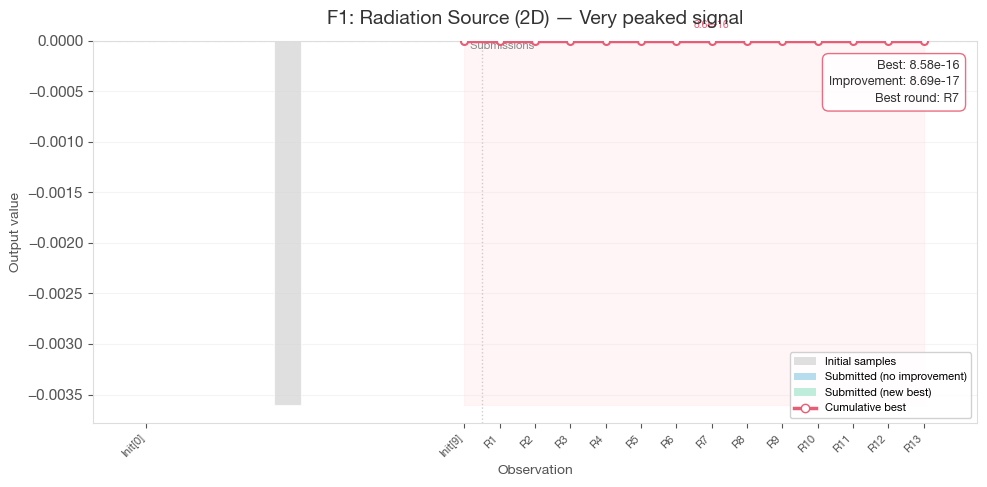

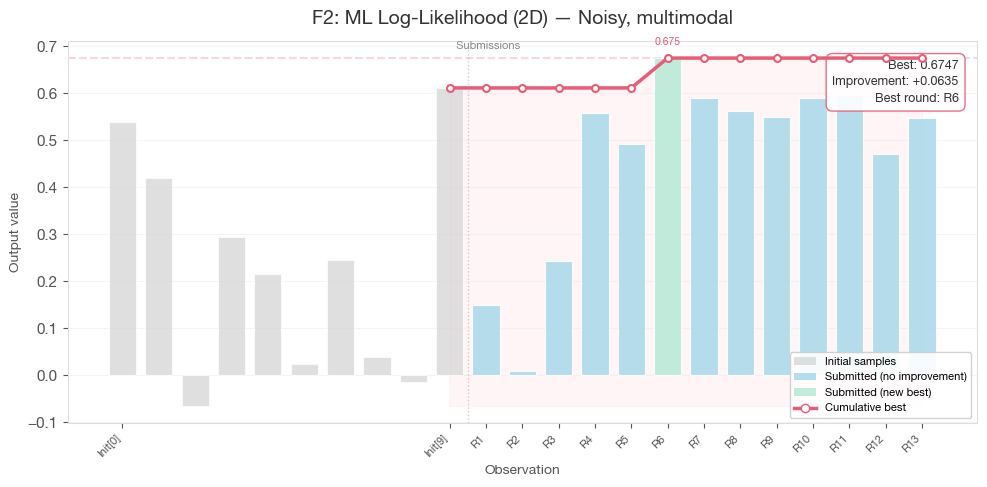

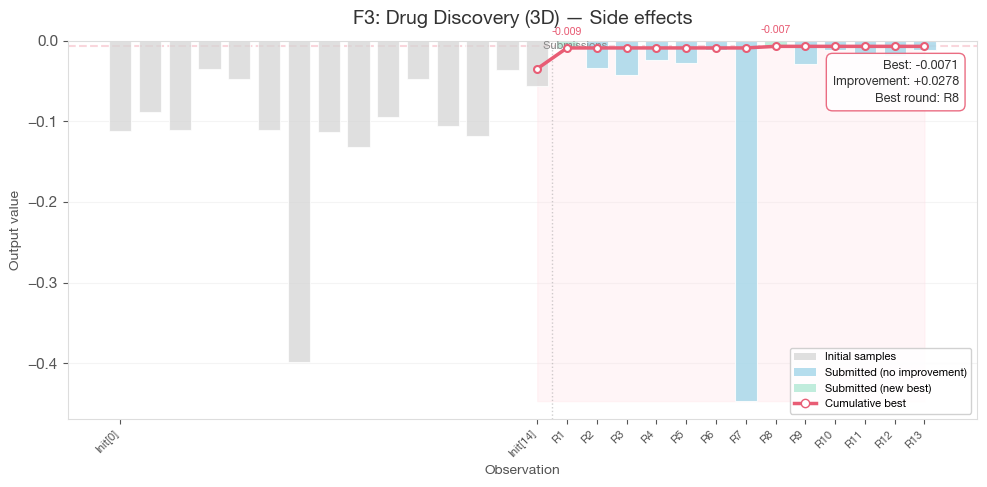

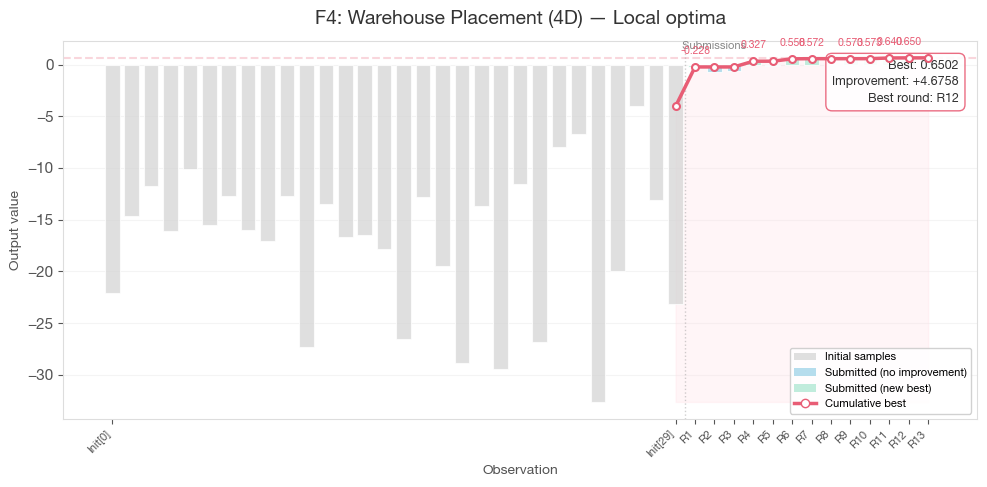

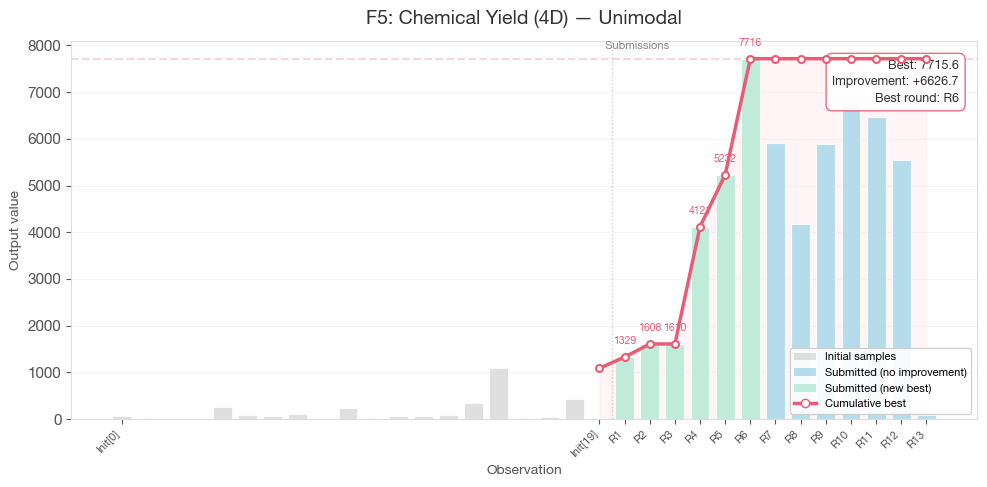

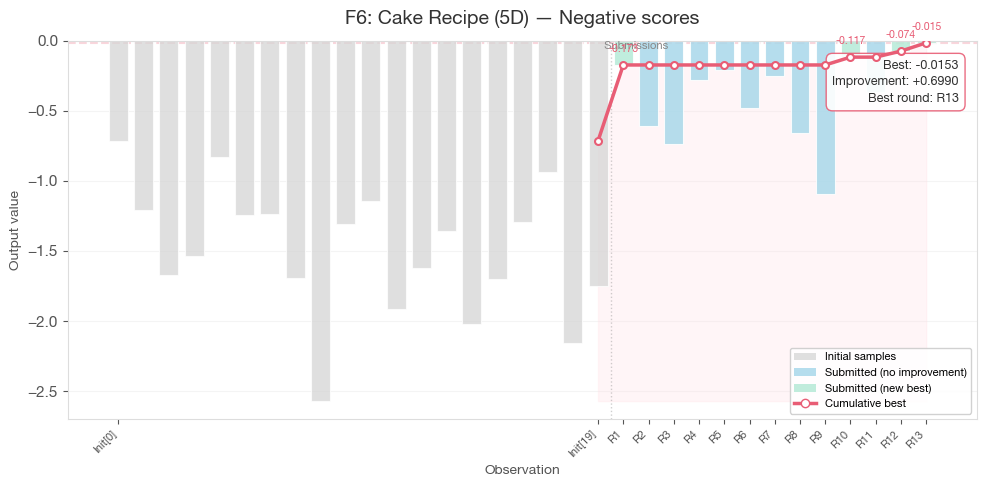

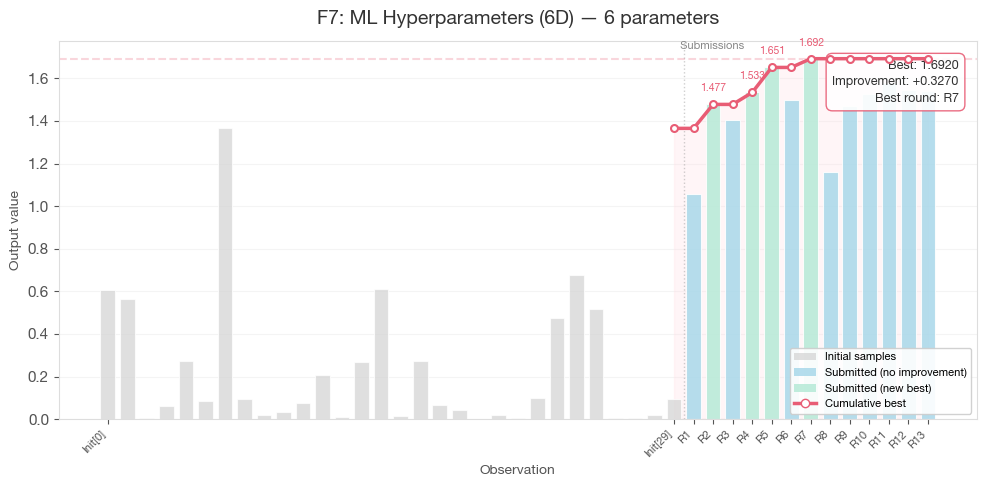

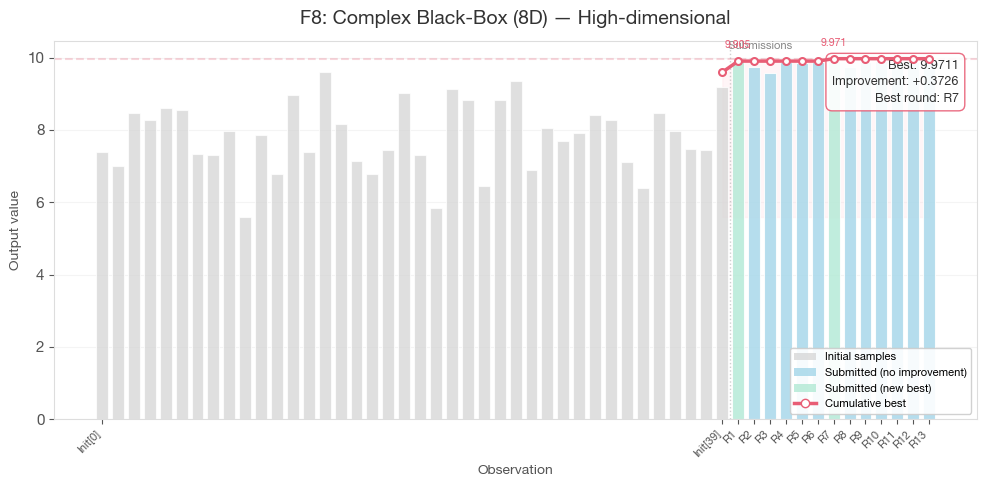

In [3]:
# Generate convergence plots for all 8 functions
for fn in range(1, 9):
    plot_convergence(fn)

## 2. GP Surrogate Surfaces — F1 and F2 (2D functions)

For the two 2D functions, we can visualise the full GP surrogate surface as a 3D plot.
- **Left**: GP mean surface showing predicted function values across the domain
- **Right**: Same surface with contour projection on the floor, showing level sets

In [4]:
def plot_gp_surface_2d(fn, save=True):
    """Generate 3D GP surface plot for a 2D function (F1 or F2)."""
    info = FUNC_INFO[fn]
    n_init = info["n_init"]
    X, y = load_all_data(fn)
    gp = fit_gp_model(X, y, random_state=42)

    n = 100
    xx = np.linspace(0, 1, n)
    gx, gy = np.meshgrid(xx, xx)
    grid_pts = np.c_[gx.ravel(), gy.ravel()]
    mu = gp.predict(grid_pts).reshape(n, n)

    best_idx = np.argmax(y)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})
    fig.suptitle(f"{info['name']} ({info['dim']}) — GP Surrogate Surface",
                 fontsize=14, fontweight='bold', y=0.98, color='#333333')

    for ax_idx, ax in enumerate(axes):
        surf = ax.plot_surface(gx, gy, mu, cmap='viridis',
                               alpha=0.7 if ax_idx == 0 else 0.5,
                               linewidth=0, antialiased=True)

        if ax_idx == 1:
            ax.contourf(gx, gy, mu, levels=30, cmap='viridis', offset=mu.min(), alpha=0.6)

        # Data points
        ax.scatter(X[:n_init, 0], X[:n_init, 1], y[:n_init],
                   c=PASTEL_GRAY, edgecolors='#888888', s=40, zorder=5,
                   label='Initial', depthshade=False)
        ax.scatter(X[n_init:, 0], X[n_init:, 1], y[n_init:],
                   c=PASTEL_BLUE, edgecolors='#555555', s=40, marker='D', zorder=5,
                   label='Submitted', depthshade=False)

        # Best point
        best_label = f'Best: {y.max():.2e}' if fn == 1 else f'Best: {y.max():.4f}'
        ax.scatter(X[best_idx, 0], X[best_idx, 1], y[best_idx],
                   c=BEST_COLOR, s=120, marker='*', zorder=6,
                   label=best_label, depthshade=False)

        ax.set_xlabel('x\u2081', labelpad=8, color='#555555')
        ax.set_ylabel('x\u2082', labelpad=8, color='#555555')
        ax.set_zlabel('f(x)', labelpad=8, color='#555555')

        if ax_idx == 0:
            ax.set_title('GP Mean Surface', fontsize=11, pad=10, color='#333333')
            ax.legend(fontsize=7, loc='upper left')
            fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.08, label='GP mean')
            ax.view_init(elev=25, azim=-45)
        else:
            ax.set_title('Surface with Contour Projection', fontsize=11, pad=10, color='#333333')
            ax.view_init(elev=35, azim=-60)

    plt.tight_layout()
    if save:
        fig.savefig(f'results/per_function/f{fn}_surface.png',
                    dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

print("GP surface plot function defined.")

GP surface plot function defined.


/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


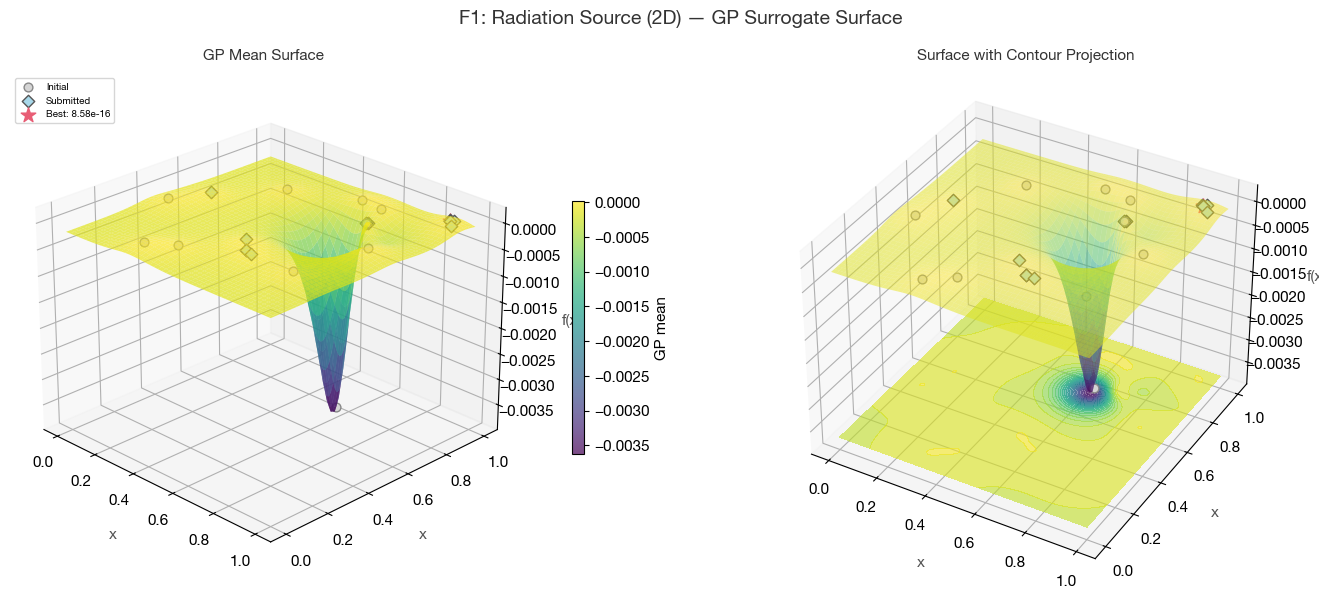

In [5]:
# F1: Radiation Source — GP Surface
plot_gp_surface_2d(1)

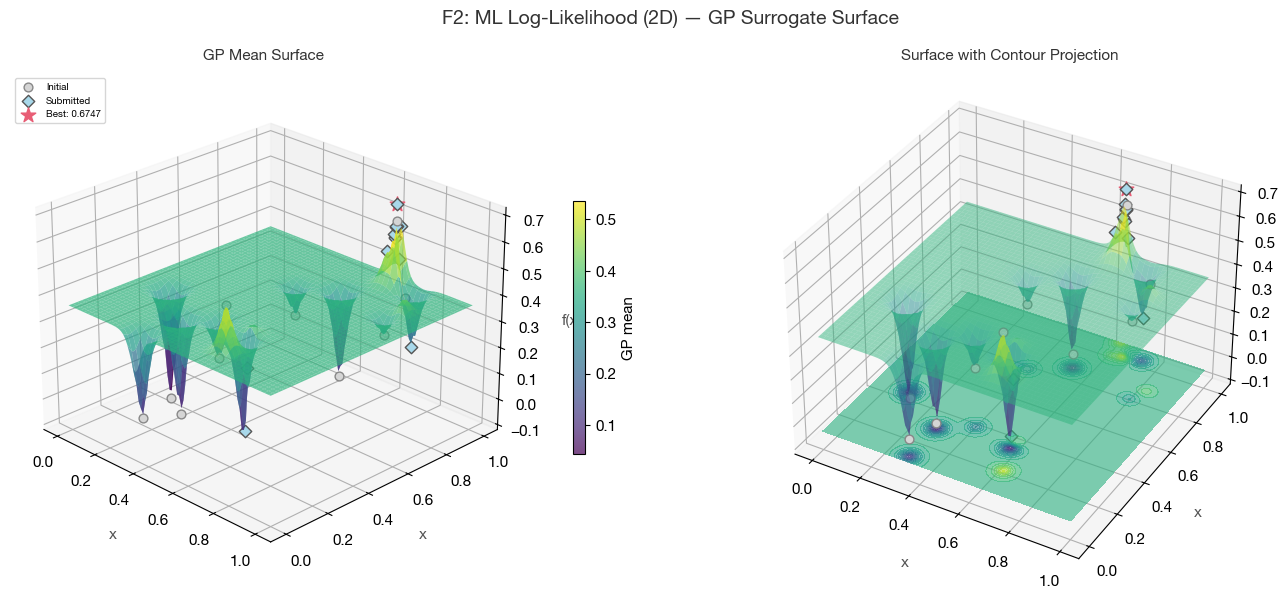

In [6]:
# F2: ML Log-Likelihood — GP Surface
plot_gp_surface_2d(2)

## 3. GP Surrogate Slices — F3 (3D function)

For F3 (3D input), we cannot show a full surface. Instead, we show three 2D slices through the best-known point, fixing one dimension at a time and varying the other two. This reveals the GP's model of the landscape around the optimum.

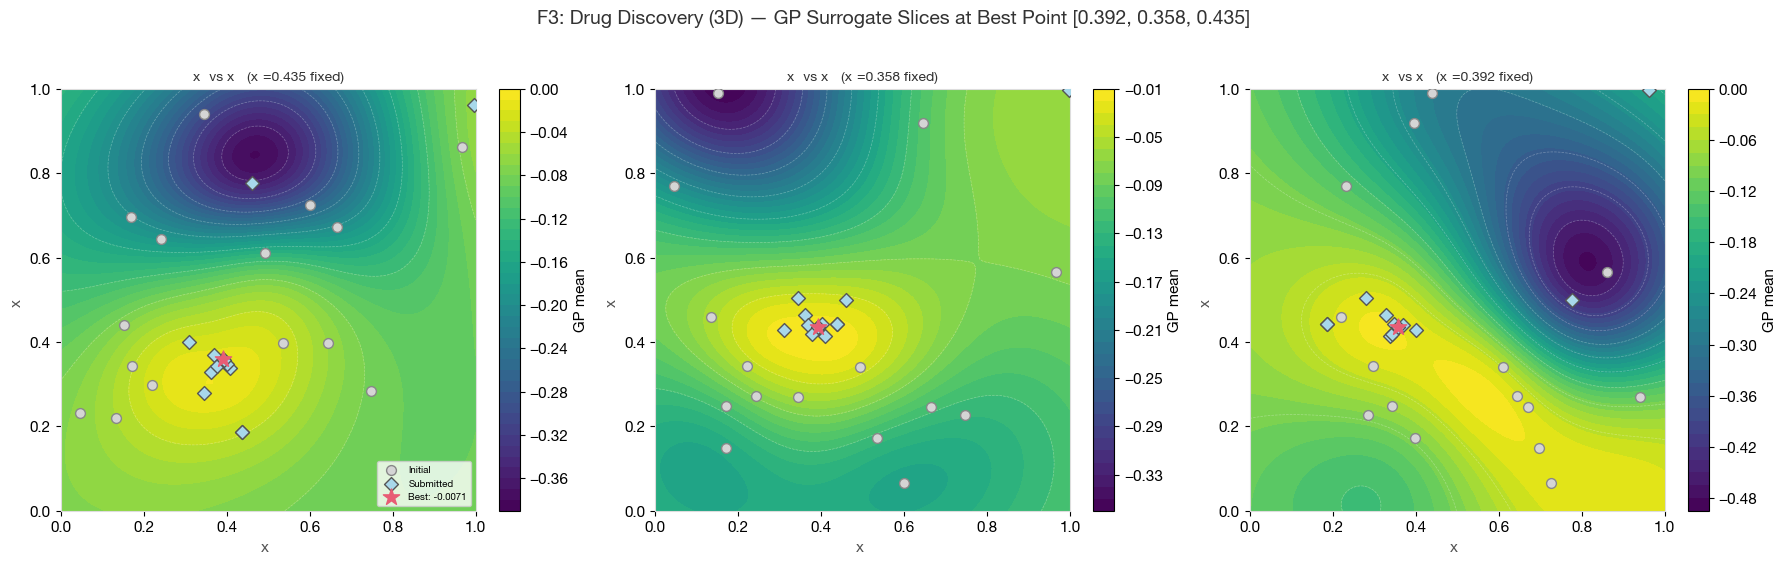

In [7]:
def plot_gp_slices_3d(fn=3, save=True):
    """Generate 2D slice plots through the best point for a 3D function."""
    info = FUNC_INFO[fn]
    n_init = info["n_init"]
    X, y = load_all_data(fn)
    gp = fit_gp_model(X, y, random_state=42)
    best_idx = np.argmax(y)
    best_pt = X[best_idx]

    n = 100
    xx = np.linspace(0, 1, n)
    dim_names = ['x\u2081', 'x\u2082', 'x\u2083']
    slice_pairs = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    fig.suptitle(
        f"{info['name']} ({info['dim']}) — GP Surrogate Slices at Best Point "
        f"[{best_pt[0]:.3f}, {best_pt[1]:.3f}, {best_pt[2]:.3f}]",
        fontsize=14, fontweight='bold', y=1.02, color='#333333')

    for i, (d1, d2, d_fix) in enumerate(slice_pairs):
        ax = axes[i]
        g1, g2 = np.meshgrid(xx, xx)

        grid_3d = np.zeros((n * n, 3))
        grid_3d[:, d1] = g1.ravel()
        grid_3d[:, d2] = g2.ravel()
        grid_3d[:, d_fix] = best_pt[d_fix]

        mu = gp.predict(grid_3d).reshape(n, n)

        cf = ax.contourf(g1, g2, mu, levels=40, cmap='viridis')
        ax.contour(g1, g2, mu, levels=10, colors='white', alpha=0.3, linewidths=0.5)
        fig.colorbar(cf, ax=ax, fraction=0.046, label='GP mean')

        # Data points projected onto this slice
        ax.scatter(X[:n_init, d1], X[:n_init, d2],
                   c=PASTEL_GRAY, edgecolors='#888888', s=50, zorder=5, label='Initial')
        ax.scatter(X[n_init:, d1], X[n_init:, d2],
                   c=PASTEL_BLUE, edgecolors='#555555', s=50, marker='D', zorder=5, label='Submitted')
        ax.scatter(best_pt[d1], best_pt[d2],
                   c=BEST_COLOR, s=150, marker='*', zorder=6, label=f'Best: {y.max():.4f}')

        ax.set_xlabel(dim_names[d1], color='#555555')
        ax.set_ylabel(dim_names[d2], color='#555555')
        ax.set_title(
            f'{dim_names[d1]} vs {dim_names[d2]}  ({dim_names[d_fix]}={best_pt[d_fix]:.3f} fixed)',
            fontsize=10, color='#333333')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        if i == 0:
            ax.legend(fontsize=7, loc='lower right')
        for spine in ax.spines.values():
            spine.set_color('#DDDDDD')

    plt.tight_layout()
    if save:
        fig.savefig(f'results/per_function/f{fn}_surface.png',
                    dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

# Generate F3 slices
plot_gp_slices_3d(3)